- 캐글 설치

In [1]:
!pip install kaggle

- 캐글에서 titanic 데이터셋 다운로드 및 압축해제
- train.csv 로딩 후 데이터 크기 확인

In [2]:
import os 
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  LabelEncoder
import matplotlib.pyplot as plt
import koreanize_matplotlib
# 캐글 API를 사용하여 타이타닉 데이터셋 다운로드 (경연 대회 데이터)
# 터미널 명령어인 '!kaggle competitions download -c titanic' 과 동일한 역할 수행
os.system('kaggle competitions download -c titanic')

# 다운로드된 압축 파일 해제 (운영체제에 따라 zipfile 라이브러리 사용 권장)
import zipfile
with zipfile.ZipFile('titanic.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# CSV 파일 읽기
df = pd.read_csv('train.csv')

# 데이터 확인
df.head(10)


C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.0)
  from scipy.sparse import csr_matrix, issparse


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


- 결측치 확인 및 대체

In [3]:
# 결측치 확인


# 1. Age(나이) 결측치: 데이터의 중앙값(median)으로 대체
df['Age'] = df['Age'].fillna(df['Age'].median())  


# 2. Embarked(탑승 항구) 결측치: 최빈값(mode)으로 대체 (결측치가 2개뿐이므로)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Cabin(객실 번호) 결측치: 결측치가 너무 많아(600개 이상) 열 자체를 삭제하거나, 
# 결측치 자체를 의미 있는 'Unknown'이라는 범주로 대체할 수 있습니다.
# 여기서는 'U' (Unknown)로 대체합니다.
df['Cabin'] = df['Cabin'].fillna('U') 

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,U,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


- 성별(sex)과 탑승 항구(Embarked) 컬럼 인코딩

In [4]:
# 1. Sex(성별): 'male', 'female' 두 가지이므로 0과 1로 매핑 (Label Encoding과 유사)
sex_mapping = { 'male' : 0 , 'female' : 1 }
df['Sex_mapped'] = df['Sex'].map( sex_mapping)

# 2. Embarked(탑승 항구): 'C', 'Q', 'S' 세 가지이며 순서가 없으므로 원-핫 인코딩
# pd.get_dummies를 사용하고 기존 컬럼은 삭제, 다중공선성 방지를 위해 drop_first=True 적용
df = pd.get_dummies( df, columns=['Embarked'], drop_first=True)


df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_mapped,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,0,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,1,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,1,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,0,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,1,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,U,1,False,True
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,0,False,False


- 지금까지 작업한 내용 확인

In [5]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_mapped,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,0,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,1,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,1,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,0,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,1,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,U,1,False,True
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,0,False,False


- 나이(Age)와 요금(Fare)는 표준화 작업( 컬럼명 : 'Age_scaled', 'Fare_scaled' )

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# StandardScaler를 사용하여 평균 0, 표준편차 1로 맞춤
std_scaler = StandardScaler()
df[['Age_scaled','Fare_scaled']] = pd.DataFrame(std_scaler.fit_transform( df[['Age','Fare']] ))

# 2차원 배열 형태로 입력해야 하므로 [['Age', 'Fare']] 형태로 묶어줌
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_mapped,Embarked_Q,Embarked_S,Age_scaled,Fare_scaled
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,0,False,True,-0.565736,-0.502445
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,False,False,0.663861,0.786845
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,1,False,True,-0.258337,-0.488854
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,1,False,True,0.433312,0.420730
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,0,False,True,0.433312,-0.486337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,0,False,True,-0.181487,-0.386671
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,1,False,True,-0.796286,-0.044381
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,U,1,False,True,-0.104637,-0.176263
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,0,False,False,-0.258337,-0.044381


- 요금은 로그변환, 나이는 5개의 범주형 그룹으로 구간화
- 0, 12, 18, 35, 60, 100
- 'Child', 'Teenager', 'Young Adult', 'Adult', 'Senior'

In [7]:


# 1. 데이터 변환: 요금(Fare) 데이터의 비대칭성을 줄이기 위해 로그 변환 적용
# 요금이 0인 경우가 있으므로 np.log1p (log(1+x)) 사용
df['Log_Fare'] = np.log1p(df['Fare'])

# 2. 구간화(Binning): 나이(Age)를 5개의 범주형 그룹으로 나눔


bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young', 'Adult', 'Senior']
df['Age_Group'] = pd.cut( df['Age'] , bins=bins, labels=labels)

df




,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_mapped,Embarked_Q,Embarked_S,Age_scaled,Fare_scaled,Log_Fare,Age_Group
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,0,False,True,-0.565736,-0.502445,2.110213,Young
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,False,False,0.663861,0.786845,4.280593,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,1,False,True,-0.258337,-0.488854,2.188856,Young
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,1,False,True,0.433312,0.420730,3.990834,Young
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,0,False,True,0.433312,-0.486337,2.202765,Young
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,0,False,True,-0.181487,-0.386671,2.639057,Young
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,1,False,True,-0.796286,-0.044381,3.433987,Young
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,U,1,False,True,-0.104637,-0.176263,3.196630,Young
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,0,False,False,-0.258337,-0.044381,3.433987,Young


- 파생변수(FamilySize : 가족수) 생성
- 가족 수 = 형제/배우자 수 + 부모/자녀 수 + 1(본인)
- 가족 규모에 따라 혼자 탑승했는지(IsAlone) 여부를 나타내는 파생 변수 추가 생성
- 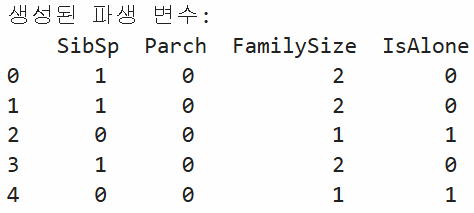

In [8]:
# 가족 수 = 형제/배우자 수 + 부모/자녀 수 + 1(본인)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1


# 가족 규모에 따라 혼자 탑승했는지(IsAlone) 여부를 나타내는 파생 변수 추가 생성

df['IsAlone'] = df['FamilySize'] == 1

df



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_mapped,Embarked_Q,Embarked_S,Age_scaled,Fare_scaled,Log_Fare,Age_Group,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,0,False,True,-0.565736,-0.502445,2.110213,Young,2,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,False,False,0.663861,0.786845,4.280593,Adult,2,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,1,False,True,-0.258337,-0.488854,2.188856,Young,1,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,1,False,True,0.433312,0.420730,3.990834,Young,2,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,0,False,True,0.433312,-0.486337,2.202765,Young,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,0,False,True,-0.181487,-0.386671,2.639057,Young,1,True
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,1,False,True,-0.796286,-0.044381,3.433987,Young,1,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,U,1,False,True,-0.104637,-0.176263,3.196630,Young,4,False
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,0,False,False,-0.258337,-0.044381,3.433987,Young,1,True


- 작업결과 출력

In [9]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_mapped,Embarked_Q,Embarked_S,Age_scaled,Fare_scaled,Log_Fare,Age_Group,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,U,0,False,True,-0.565736,-0.502445,2.110213,Young,2,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,1,False,False,0.663861,0.786845,4.280593,Adult,2,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,U,1,False,True,-0.258337,-0.488854,2.188856,Young,1,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,1,False,True,0.433312,0.420730,3.990834,Young,2,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,U,0,False,True,0.433312,-0.486337,2.202765,Young,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,U,0,False,True,-0.181487,-0.386671,2.639057,Young,1,True
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,1,False,True,-0.796286,-0.044381,3.433987,Young,1,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,U,1,False,True,-0.104637,-0.176263,3.196630,Young,4,False
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,0,False,False,-0.258337,-0.044381,3.433987,Young,1,True


- 불필요한 컬럼 삭제( 'Ticket', 'Name' )

In [25]:
df.drop(columns=['Ticket','Name'])

df.shape
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Sex_mapped,Embarked_Q,Embarked_S,Age_scaled,Fare_scaled,Log_Fare,Age_Group,FamilySize,IsAlone,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,0,False,True,-0.565736,-0.502445,2.110213,Young,2,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,1,False,False,0.663861,0.786845,4.280593,Adult,2,False,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,1,False,True,-0.258337,-0.488854,2.188856,Young,1,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,1,False,True,0.433312,0.420730,3.990834,Young,2,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0,False,True,0.433312,-0.486337,2.202765,Young,1,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,...,0,False,True,-0.181487,-0.386671,2.639057,Young,1,True,False
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,...,1,False,True,-0.796286,-0.044381,3.433987,Young,1,True,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,...,1,False,True,-0.104637,-0.176263,3.196630,Young,4,False,False
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,...,0,False,False,-0.258337,-0.044381,3.433987,Young,1,True,True


In [11]:
survived_by_FS = df.groupby('FamilySize')['Survived'].mean()
survived_by_FS

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

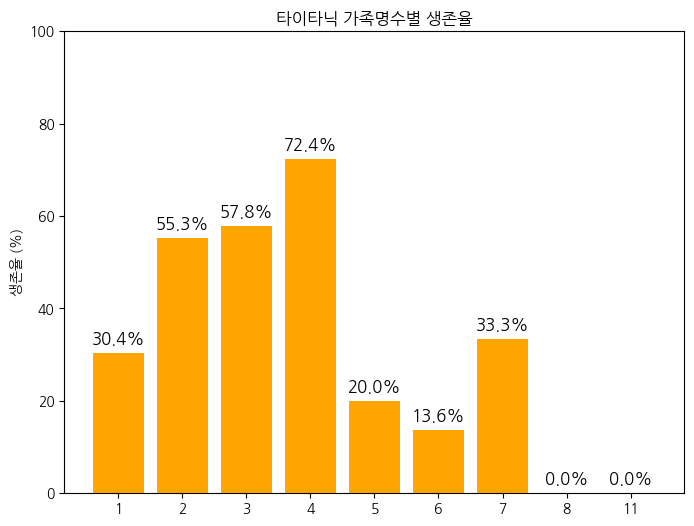

In [12]:
plt.figure(figsize=(8,6))
x = range(len(survived_by_FS))
plt.bar(x, survived_by_FS * 100, color='orange')
plt.xticks(x, survived_by_FS.index)
plt.title('타이타닉 가족명수별 생존율')
plt.ylabel('생존율 (%)') 
plt.ylim(0, 100)

for i, v in enumerate(survived_by_FS * 100):
    plt.text(
        i, v + 2,                       # 위치: 막대보다 살짝 위
        f"{v:.1f}%",                    # 소수점 1자리 퍼센트
        ha='center', fontsize=12
    )

In [22]:
survived_by_AF = df.groupby('IsAlone')['Survived'].mean()
survived_by_AF

IsAlone
False    0.505650
True     0.303538
Name: Survived, dtype: float64

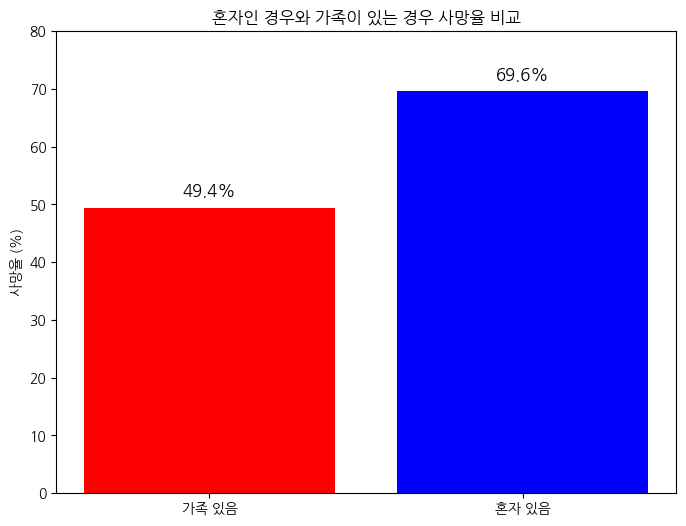

In [23]:
plt.figure(figsize=(8,6))
x = range(len(survived_by_AF))
death_rate = 1 - survived_by_AF
plt.bar(x, death_rate * 100, color=['red', 'blue'])
plt.xticks(x, ['가족 있음', '혼자 있음'])
plt.title('혼자인 경우와 가족이 있는 경우 사망율 비교')
plt.ylabel('사망율 (%)') 
plt.ylim(0, 80)

for i, v in enumerate(death_rate * 100):
    plt.text(
        i, v + 2,                       # 위치: 막대보다 살짝 위
        f"{v:.1f}%",                    # 소수점 1자리 퍼센트
        ha='center', fontsize=12
    )

In [15]:
df['HasCabin'] = df['Cabin'] != 'U'

In [16]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,Sex_mapped,Embarked_Q,Embarked_S,Age_scaled,Fare_scaled,Log_Fare,Age_Group,FamilySize,IsAlone,HasCabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,0,False,True,-0.565736,-0.502445,2.110213,Young,2,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,1,False,False,0.663861,0.786845,4.280593,Adult,2,False,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,1,False,True,-0.258337,-0.488854,2.188856,Young,1,True,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,1,False,True,0.433312,0.420730,3.990834,Young,2,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,0,False,True,0.433312,-0.486337,2.202765,Young,1,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,...,0,False,True,-0.181487,-0.386671,2.639057,Young,1,True,False
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,...,1,False,True,-0.796286,-0.044381,3.433987,Young,1,True,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,...,1,False,True,-0.104637,-0.176263,3.196630,Young,4,False,False
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,...,0,False,False,-0.258337,-0.044381,3.433987,Young,1,True,True


In [17]:
survived_by_C = df.groupby('HasCabin')['Survived'].mean()
survived_by_C

HasCabin
False    0.299854
True     0.666667
Name: Survived, dtype: float64

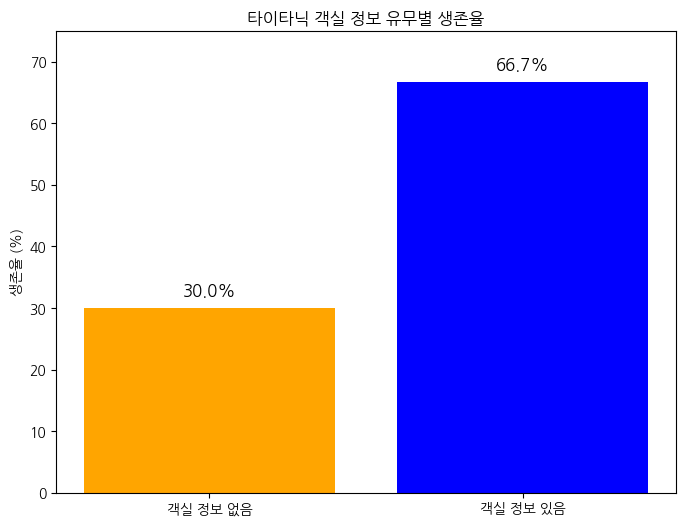

In [18]:
plt.figure(figsize=(8,6))
x = range(len(survived_by_C))
plt.bar(x, survived_by_C * 100, color=['orange', 'Blue'])
plt.xticks(x, ['객실 정보 없음', '객실 정보 있음'])
plt.title('타이타닉 객실 정보 유무별 생존율')
plt.ylabel('생존율 (%)') 
plt.ylim(0, 75)

for i, v in enumerate(survived_by_C * 100):
    plt.text(
        i, v + 2,                       # 위치: 막대보다 살짝 위
        f"{v:.1f}%",                    # 소수점 1자리 퍼센트
        ha='center', fontsize=12
    )

In [19]:
survived_by_AS = df.groupby(['Age_Group','Sex'])['Survived'].mean()
survived_by_AS

C:\Users\User\AppData\Local\Temp\ipykernel_21572\1729956302.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survived_by_AS = df.groupby(['Age_Group','Sex'])['Survived'].mean()


Age_Group  Sex   
Child      female    0.593750
           male      0.567568
Teen       female    0.750000
           male      0.088235
Young      female    0.751445
           male      0.162983
Adult      female    0.771429
           male      0.192000
Senior     female    1.000000
           male      0.105263
Name: Survived, dtype: float64

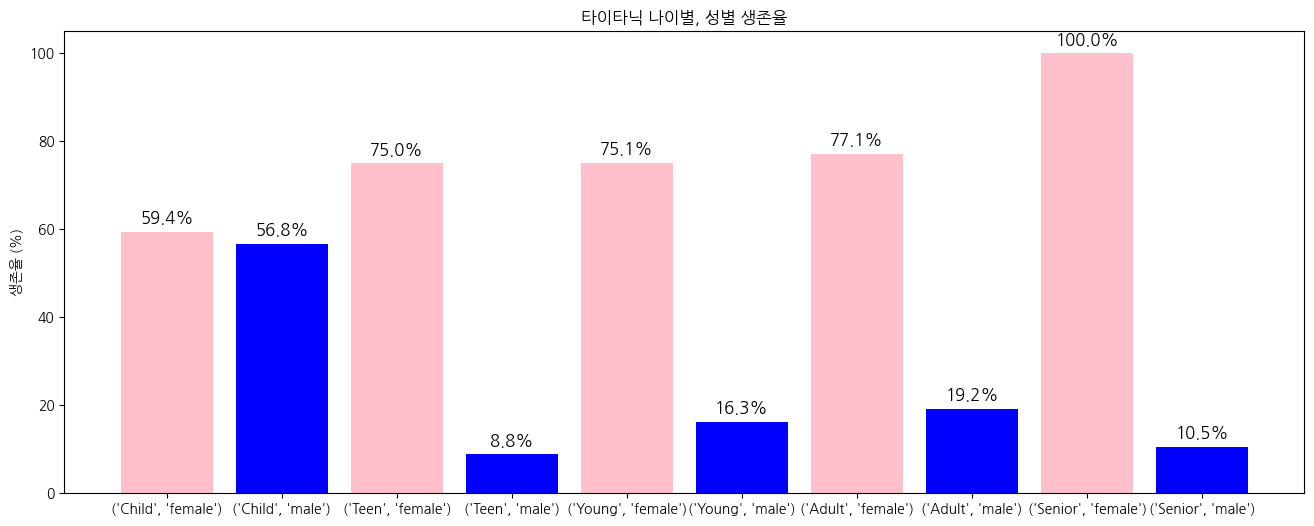

In [21]:
plt.figure(figsize=(16,6))
x = range(len(survived_by_AS))
plt.bar(x, survived_by_AS * 100, color=['pink', 'Blue'])
plt.xticks(x, survived_by_AS.index)
plt.title('타이타닉 나이별, 성별 생존율')
plt.ylabel('생존율 (%)') 
plt.ylim(0, 105)

for i, v in enumerate(survived_by_AS * 100):
    plt.text(
        i, v + 2,                       # 위치: 막대보다 살짝 위
        f"{v:.1f}%",                    # 소수점 1자리 퍼센트
        ha='center', fontsize=12
    )